<a href="https://colab.research.google.com/github/06aslan30/VRSU/blob/main/VRSU_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving westeros.jpg to westeros.jpg


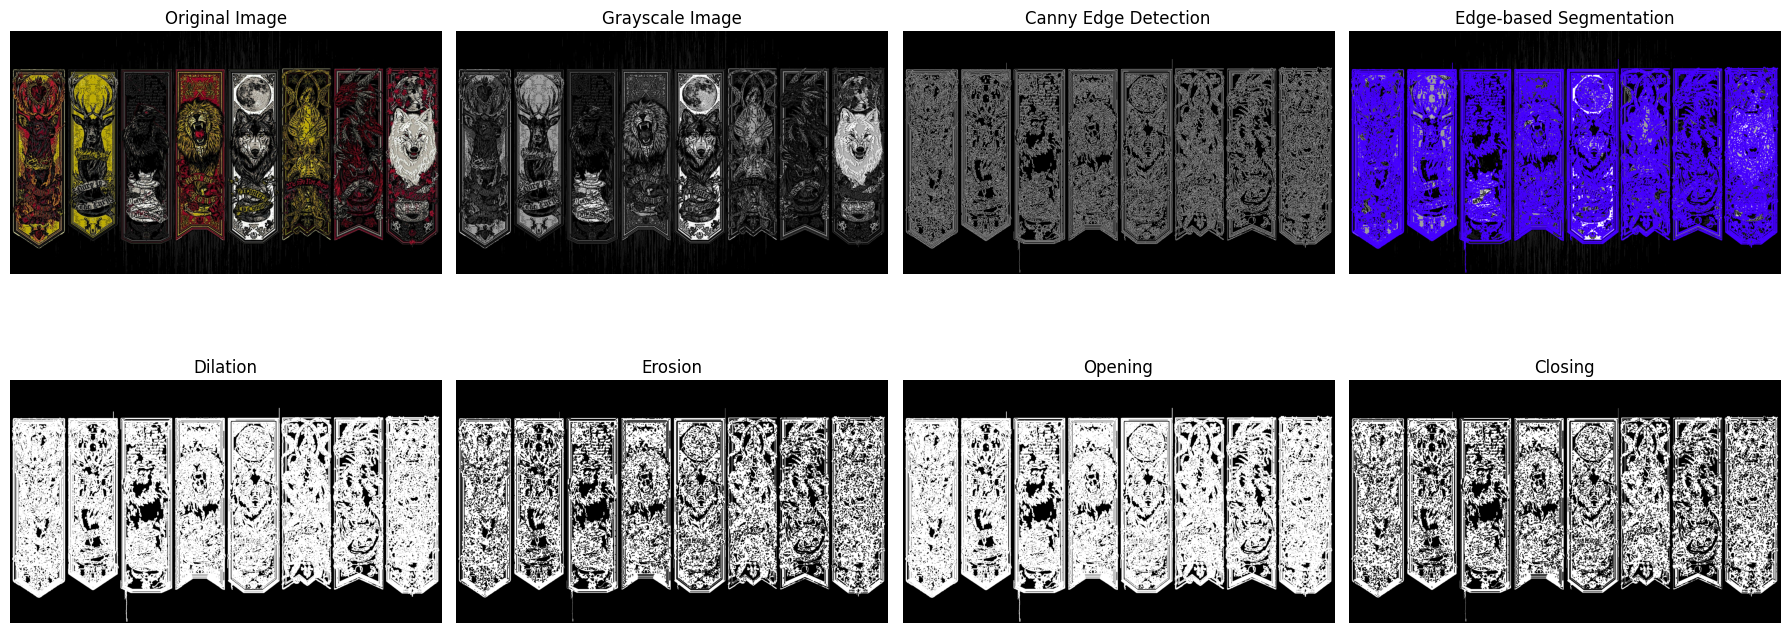

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# Step 1: Upload and Read Image
# -----------------------------
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img_gray = cv2.imread(image_path, 0)
img_color = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

if img_gray is None:
    raise ValueError("Image not loaded properly")

# Save original images
# For img_rgb, we need to convert it back to BGR for OpenCV saving
cv2.imwrite(f'original_{image_path}', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(f'grayscale_{image_path}', img_gray)

# -----------------------------
# Step 2: Edge Detection (Canny)
# -----------------------------
edges = cv2.Canny(img_gray, 50, 200)
cv2.imwrite(f'canny_edges_{image_path}', edges)

# -----------------------------
# Step 3: Contour-Based Segmentation
# -----------------------------
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

segmented = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(segmented, contours, -1, (69, 0, 255), 2)
cv2.imwrite(f'segmented_{image_path}', segmented)

# -----------------------------
# Step 4: Morphological Operations
# -----------------------------
kernel = np.ones((3, 3), np.uint8)

dilated = cv2.dilate(edges, kernel, iterations=1)
eroded = cv2.erode(dilated, kernel, iterations=1)
opening = cv2.morphologyEx(dilated, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

cv2.imwrite(f'dilated_{image_path}', dilated)
cv2.imwrite(f'eroded_{image_path}', eroded)
cv2.imwrite(f'opening_{image_path}', opening)
cv2.imwrite(f'closing_{image_path}', closing)

# -----------------------------
# Step 5: Display Results
# -----------------------------
plt.figure(figsize=(18, 8)) # Adjusted figure size for more plots

plt.subplot(2, 4, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(2, 4, 2)
plt.title("Grayscale Image")
plt.imshow(img_gray, cmap="gray")
plt.axis("off")

plt.subplot(2,4,3)
plt.title("Canny Edge Detection")
plt.imshow(edges, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.title("Edge-based Segmentation")
plt.imshow(segmented)
plt.axis("off")

plt.subplot(2, 4, 5)
plt.title("Dilation")
plt.imshow(dilated, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.title("Erosion")
plt.imshow(eroded, cmap="gray") # Added erosion to the display
plt.axis("off")

plt.subplot(2, 4, 7)
plt.title("Opening")
plt.imshow(opening, cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.title("Closing")
plt.imshow(closing, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
import os

print("Files in current directory:")
for f in os.listdir('.'):
    print(f)

Files in current directory:
.config
grayscale_image.jpg
opening_image.jpg
BOAR.png
claws.jpg
spirit of vengeance.jpg
canny_edges.jpg
114522.png
claws (1).jpg
closing_image.jpg
claws (3).jpg
rengoku (1).jpg
claws (4).jpg
segmented_image.jpg
dilated_image.jpg
rengoku.jpg
eroded_image.jpg
claws (5).jpg
original_image.jpg
claws (2).jpg
sample_data
